# **BootCamp Inteligencia Artificial - SomosF5**        
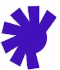

## **Módulo 2**
## **Temática a desarrollar**: **Probabilidad básica · Condicional · Bayes (conceptual)**


---
## 📦 Paso 0: Importar herramientas

Primero cargamos las librerías que necesitamos. Piensa en ellas como la caja de herramientas de un mecánico.

In [289]:
import random          # Genera números aleatorios
import matplotlib.pyplot as plt  # Hace gráficas
# Submódulo de matplotlib para dibujar formas geométricas (rectángulos, flechas, círculos). Añade elementos decorativos a los gráficos, como leyendas personalizadas.
import matplotlib.patches as mpatches
import numpy as np     # Para cálculos numéricos
#Importa solo la clase Counter del módulo collections. Cuenta cuántas veces aparece cada elemento en una lista — Ej: Cuántas veces salió cada número al lanzar un dado.
from collections import Counter  # Cuenta los resultados

# Colores 🎨
COLOR_PURPLE = '#4211BA'
COLOR_CYAN   = '#33C6CD'

#rcParams es el diccionario de configuración global de matplotlib. dpi = dots per inch — controla la resolución de los gráficos. 100 es un valor estándar, equilibrado entre calidad y rendimiento.
plt.rcParams['figure.dpi'] = 100
#Oculta los bordes superior y derecho de los gráficos. Es un ajuste estético muy habitual — hace que las gráficas se vean más limpias y modernas, sin el "marco" completo alrededor.
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('✅ Todo listo para empezar!')

✅ Todo listo para empezar!


---
## 🪙 Parte 1: Probabilidad Básica — La Moneda

### ¿Qué es la probabilidad?

La probabilidad mide **qué tan probable** es que algo pase:
- `0` = imposible (nunca va a pasar)
- `1` = seguro (siempre pasa)
- `0.5` = hay 50/50 de chance

**Fórmula básica:**
$$P(\text{evento}) = \frac{\text{casos favorables}}{\text{total de casos posibles}}$$

Para una moneda: P(cara) = 1/2 = 0.5 = 50%
$$P(\text{cara}) = \frac{\text{1}}{\text{2}} = 0.5 = 50% $$

In [290]:
# ============================================
# 🪙 SIMULACIÓN 1: Lanzar una moneda
# ============================================

# 🔧 Modifica este número y ve qué pasa:
N_LANZAMIENTOS = 100  # Prueba con 10, 100, 1000, 10000

# Simular los lanzamientos
#random.choice() :  elige un elemento al azar de una lista.
resultados = [random.choice(['Cara', 'Cruz']) for _ in range(N_LANZAMIENTOS)]

# Cuenta los resultados
conteo = Counter(resultados)
#formula anterior p(cara) = casos favorables / total de casos posibles
p_cara = conteo['Cara'] / N_LANZAMIENTOS
p_cruz = conteo['Cruz'] / N_LANZAMIENTOS

print(f'🪙 Se lanza la moneda {N_LANZAMIENTOS:,} veces')
print(f'   Cara: {conteo["Cara"]:,} veces  →  P(Cara) = {p_cara:.3f} ({p_cara*100:.1f}%)')
print(f'   Cruz: {conteo["Cruz"]:,} veces  →  P(Cruz) = {p_cruz:.3f} ({p_cruz*100:.1f}%)')
print(f'\n📐 Valor teórico esperado: P(Cara) = 0.500 (50.0%)')
# abs calcula el valor absoluto - distancia entre lo que salió y lo que era esperado, siempre positiva
print(f'🎯 Error de la simulación: {abs(p_cara - 0.5):.4f}')

🪙 Se lanza la moneda 100 veces
   Cara: 54 veces  →  P(Cara) = 0.540 (54.0%)
   Cruz: 46 veces  →  P(Cruz) = 0.460 (46.0%)

📐 Valor teórico esperado: P(Cara) = 0.500 (50.0%)
🎯 Error de la simulación: 0.0400


💡 **La idea que une todo**

Cuanto mayor sea N_LANZAMIENTOS, menor será el error. Con 10 lanzamientos se puede obtener 70% de caras. Con 10.000 casi siempre se estará muy cerca del 50%. Eso es la Ley de los Grandes Números — y este código lo demuestra experimentalmente.

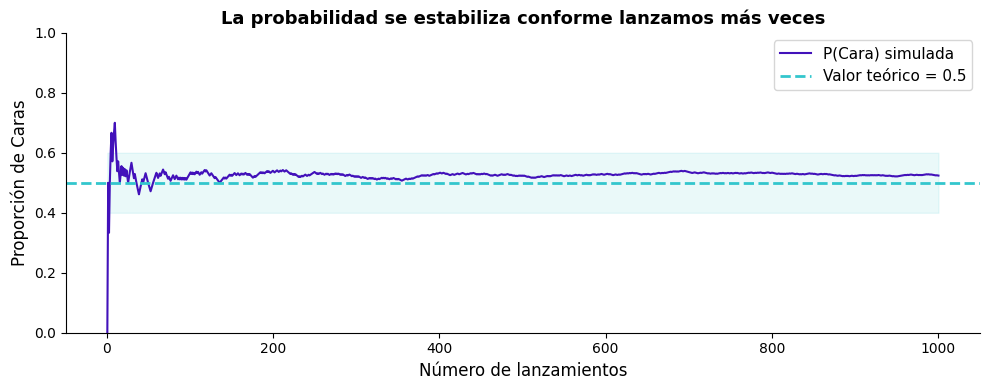

💡 Observa cómo la línea morada "converge" hacia la línea azul.
   Esto se llama la Ley de los Grandes Números.


In [291]:
# ============================================
# 📈 Gráfica: Cómo se estabiliza la probabilidad
# ============================================
#Funciona independiente del anterior
#N:  número de lanzamientos
N = 1000
# 0=Cruz, 1=Cara
#Se necesitará sumar, por eso 0 y 1.
lanzamientos = [random.choice([0, 1]) for _ in range(N)]
#Para cada momento i del experimento calcula la proporción acumulada de caras hasta ese punto.
proporciones = [sum(lanzamientos[:i+1])/(i+1) for i in range(N)]

fig, ax = plt.subplots(figsize=(10, 4))
#Se dibuja la línea principal (Color Morado)
ax.plot(range(1, N+1), proporciones, color=COLOR_PURPLE, linewidth=1.5, label='P(Cara) simulada')
#Valor teórico
ax.axhline(y=0.5, color=COLOR_CYAN, linestyle='--', linewidth=2, label='Valor teórico = 0.5')
# Franja de color celeste, zona de +-10% alrededor del valor teórico. Guía visual para ver cuándo la simulación ya se ha estabilizado dentro de ese rango
ax.fill_between(range(1, N+1), 0.4, 0.6, alpha=0.1, color=COLOR_CYAN)
#LABELs DE EJES Y TÍTULO
ax.set_xlabel('Número de lanzamientos', fontsize=12)
ax.set_ylabel('Proporción de Caras', fontsize=12)
ax.set_title('La probabilidad se estabiliza conforme lanzamos más veces', fontsize=13, fontweight='bold')
#Leyenda
ax.legend(fontsize=11)
#Fija el eje Y entre 0 y 1 (porque es probabilidad)
ax.set_ylim(0, 1)
#ajusta automaticamente los márgenes para que nada se solape
plt.tight_layout()
#Renderizamos el gráfico
plt.show()

print('💡 Observa cómo la línea morada "converge" hacia la línea azul.')
print('   Esto se llama la Ley de los Grandes Números.')

💡 **La idea que une todo el bloque**


La lista proporciones es el corazón del código — captura cómo evoluciona la probabilidad en tiempo real lanzamiento a lanzamiento. Al principio la línea salta mucho (con pocos datos, el azar domina). Conforme i crece, la línea se aplana hacia 0.5. Eso es exactamente la Ley de los Grandes Números visualizada.

---
## 🎲 Dado: Probabilidades desiguales

Un dado tiene 6 caras iguales, así que cada cara tiene la misma probabilidad.
Pero, ¿qué pasa si queremos calcular la probabilidad de sacar un número par?

In [292]:
# ============================================
# 🎲 SIMULACIÓN 2: Lanzar un dado
# ============================================

N_DADOS = 10000
#Se genera un número entero aleatorio entre 1 y 6 inclusive
resultados_dado = [random.randint(1, 6) for _ in range(N_DADOS)]

# Se calculan las probabilidades
# Cuántas veces apareció cada número dell 1 al 6
conteo_dado = Counter(resultados_dado)

#.format es igual que f string
print('🎲 Resultados de lanzar el dado {:,} veces:'.format(N_DADOS))
#formato de la tabla a mostrar, texto alineado en 8 o 10 caracteres
print(f'   {"Cara":<8} {"Conteo":>8} {"P. Sim.":>10} {"P. Teórica":>12}')
print('   ' + '-'*42)
for cara in range(1, 7):
    sim = conteo_dado[cara] / N_DADOS
    print(f'   {cara:<8} {conteo_dado[cara]:>8,} {sim:>10.3f} {1/6:>12.3f}')

# Probabilidad de par
#r % 2 operador del módulo, devuelve el resto de la división. Si es 0, el número es par
pares = sum(1 for r in resultados_dado if r % 2 == 0)
print(f'\n🟢 P(número par) = {pares:,}/{N_DADOS:,} = {pares/N_DADOS:.3f}  →  Teórico: 0.500')

🎲 Resultados de lanzar el dado 10,000 veces:
   Cara       Conteo    P. Sim.   P. Teórica
   ------------------------------------------
   1           1,653      0.165        0.167
   2           1,645      0.165        0.167
   3           1,603      0.160        0.167
   4           1,693      0.169        0.167
   5           1,632      0.163        0.167
   6           1,774      0.177        0.167

🟢 P(número par) = 5,112/10,000 = 0.511  →  Teórico: 0.500


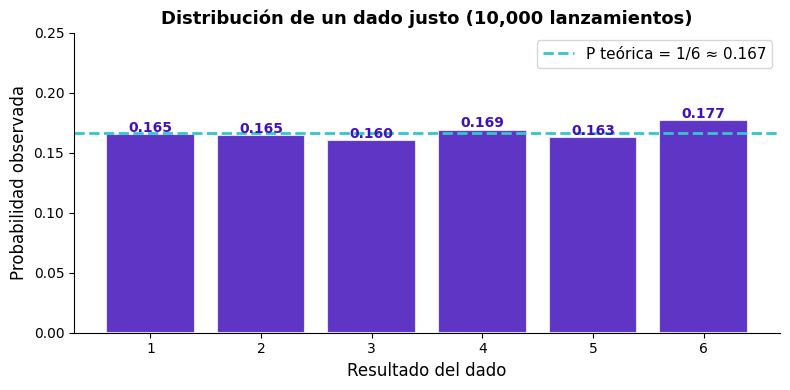

In [293]:
# Gráfica de barras
fig, ax = plt.subplots(figsize=(8, 4))
caras = list(range(1, 7))
frecuencias = [conteo_dado[c]/N_DADOS for c in caras]

bars = ax.bar(caras, frecuencias, color=COLOR_PURPLE, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(y=1/6, color=COLOR_CYAN, linestyle='--', linewidth=2, label=f'P teórica = 1/6 ≈ {1/6:.3f}')
for bar, freq in zip(bars, frecuencias):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{freq:.3f}', ha='center', fontsize=10, color=COLOR_PURPLE, fontweight='bold')
ax.set_xlabel('Resultado del dado', fontsize=12)
ax.set_ylabel('Probabilidad observada', fontsize=12)
ax.set_title(f'Distribución de un dado justo ({N_DADOS:,} lanzamientos)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 0.25)
plt.tight_layout()
plt.show()

**💡 Lo que la gráfica demuestra visualmente**



Todas las barras están casi a la misma altura y muy cerca de la línea cyan. Eso confirma que la simulación se comporta como un dado justo. Si una barra fuera claramente más alta o más baja, se sospecharía que el dado está trucado — eso es exactamente la lógica que usan los estadísticos para detectar fraude o sesgo en datos reales.

---
## 🔍 Parte 2: Probabilidad Condicional

La probabilidad **cambia** cuando se tiene información adicional.

**Notación:** P(A | B) = Probabilidad de A **dado que** B ya ocurrió

$$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$

En términos de frecuencias (que es exactamente lo que se tiene en la tabla):

$$P(A \mid B) = \frac{\text{casos donde ocurren A y B}}{\text{total de casos donde ocurre B}}$$

**Ejemplo:** Se tienen datos sobre si los estudiantes aprobaron un examen, y si estudiaron la noche anterior.

In [294]:
# ============================================
# 📚 Probabilidad Condicional: Estudio y Aprobación
# ============================================

# Datos simulados de 500 estudiantes
random.seed(42)
N = 500

estudiantes = []
for _ in range(N):
    estudio = random.random() < 0.6     # 60% estudió
    if estudio:
        aprobó = random.random() < 0.85  # 85% de los que estudiaron aprueban
    else:
        aprobó = random.random() < 0.30  # 30% de los que no estudiaron aprueban
    estudiantes.append({'estudió': estudio, 'aprobó': aprobó})

# Calcular probabilidades
total = len(estudiantes)
estudio_si = [e for e in estudiantes if e['estudió']]
estudio_no = [e for e in estudiantes if not e['estudió']]

p_aprobó_dado_estudio = sum(1 for e in estudio_si if e['aprobó']) / len(estudio_si)
p_aprobó_dado_no_estudio = sum(1 for e in estudio_no if e['aprobó']) / len(estudio_no)
p_aprobó_general = sum(1 for e in estudiantes if e['aprobó']) / total

print('📊 RESULTADOS (sobre {:,} estudiantes simulados)'.format(N))
print('='*55)
print(f'  P(aprobar)                         = {p_aprobó_general:.3f}  ({p_aprobó_general*100:.1f}%)')
print(f'  P(aprobar | SÍ estudió)            = {p_aprobó_dado_estudio:.3f}  ({p_aprobó_dado_estudio*100:.1f}%)')
print(f'  P(aprobar | NO estudió)            = {p_aprobó_dado_no_estudio:.3f}  ({p_aprobó_dado_no_estudio*100:.1f}%)')
print()
print('💡 La información de "si estudió" cambia drásticamente la probabilidad!')

📊 RESULTADOS (sobre 500 estudiantes simulados)
  P(aprobar)                         = 0.604  (60.4%)
  P(aprobar | SÍ estudió)            = 0.830  (83.0%)
  P(aprobar | NO estudió)            = 0.294  (29.4%)

💡 La información de "si estudió" cambia drásticamente la probabilidad!


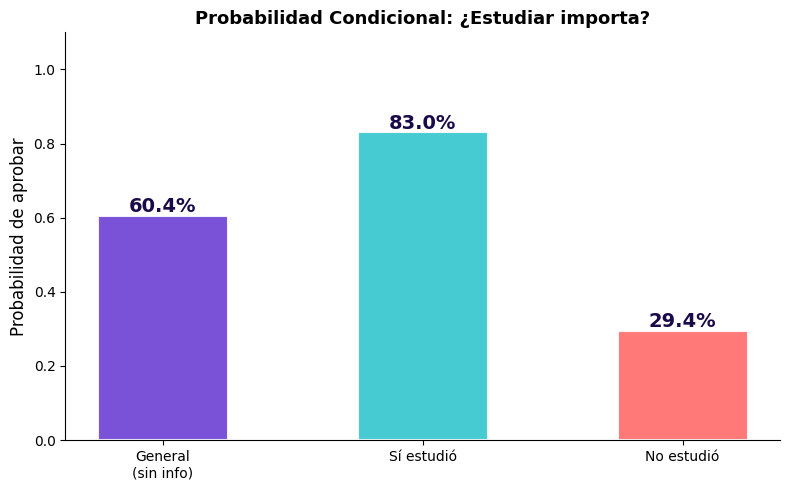


🎯 Diferencia: 53.7 puntos porcentuales más
   entre los que estudiaron vs. los que no.


In [295]:
# Gráfica comparativa
fig, ax = plt.subplots(figsize=(8, 5))

categorias = ['General\n(sin info)', 'Sí estudió', 'No estudió']
probs = [p_aprobó_general, p_aprobó_dado_estudio, p_aprobó_dado_no_estudio]
colores = ['#6B3FD4', COLOR_CYAN, '#FF6B6B']

bars = ax.bar(categorias, probs, color=colores, alpha=0.9, edgecolor='white', linewidth=1.5, width=0.5)
for bar, prob in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{prob*100:.1f}%', ha='center', fontsize=14, fontweight='bold', color='#1A0A4A')

ax.set_ylabel('Probabilidad de aprobar', fontsize=12)
ax.set_title('Probabilidad Condicional: ¿Estudiar importa?', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

print(f'\n🎯 Diferencia: {(p_aprobó_dado_estudio - p_aprobó_dado_no_estudio)*100:.1f} puntos porcentuales más')
print('   entre los que estudiaron vs. los que no.')

**💡 El mensaje clave de la gráfica**

La diferencia entre la barra 2 y la barra 3 es de 53.6 puntos porcentuales. Eso es lo que aporta la información adicional — pasar de no saber nada a saber si el estudiante estudió casi triplica o reduce a un tercio la probabilidad, dependiendo de la dirección.

Eso es exactamente lo que hace la probabilidad condicional: filtrar el universo para dar una estimación más precisa y útil.

---
## 🧠 Parte 3: Teorema de Bayes — Actualización de creencias

Bayes menciona cómo **actualizar** las creencias cuando se recibe nueva evidencia.

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

### 🏥 Escenario: Test médico

- Enfermedad rara: afecta al **1%** de la población
- El test es **95% preciso** (si tienes la enfermedad, da positivo 95% de las veces)
- Pero también tiene un **5% de falsos positivos**

**Pregunta:** Si un test da positivo, ¿qué tan probable es que realmente se tenga la enfermedad?



$$P(enfermo|positivo) = \frac{P(positivo|enfermo) \cdot P(enfermo)}{P(positivo)}$$

In [296]:
# ============================================
# 🏥 Simulación: Test médico con Bayes
# ============================================

# 🔧 Modifica estos valores y observa cómo cambia el resultado:
P_ENFERMEDAD = 0.01     # Prevalencia: 1% de la población tiene la enfermedad
P_POSITIVO_SI_ENFERMO  = 0.95  # Sensibilidad del test: 95%
P_POSITIVO_SI_SANO     = 0.05  # Tasa de falsos positivos: 5%

# Calcular con Bayes
P_SANO = 1 - P_ENFERMEDAD

# P(positivo) = P(positivo|enfermo)*P(enfermo) + P(positivo|sano)*P(sano)
P_POSITIVO = P_POSITIVO_SI_ENFERMO * P_ENFERMEDAD + P_POSITIVO_SI_SANO * P_SANO

# Bayes: P(enfermo | positivo)
P_ENFERMO_DADO_POSITIVO = (P_POSITIVO_SI_ENFERMO * P_ENFERMEDAD) / P_POSITIVO

print('🧮 CÁLCULO CON BAYES')
print('='*50)
print(f'  Prevalencia de la enfermedad:     {P_ENFERMEDAD*100:.1f}%')
print(f'  Sensibilidad del test:            {P_POSITIVO_SI_ENFERMO*100:.1f}%')
print(f'  Tasa de falsos positivos:         {P_POSITIVO_SI_SANO*100:.1f}%')
print()
print(f'  P(test positivo):                 {P_POSITIVO*100:.2f}%')
print()
print(f'  ✅ P(enfermo | test positivo) = {P_ENFERMO_DADO_POSITIVO*100:.1f}%')
print()
print('💬 Interpretación:')
if P_ENFERMO_DADO_POSITIVO < 0.5:
    print(f'   Aunque el test dio positivo, hay solo un {P_ENFERMO_DADO_POSITIVO*100:.1f}% de chance')
    print(f'   de estar realmente enfermo. ¡Los falsos positivos dominan!')
else:
    print(f'   Con un resultado positivo, hay un {P_ENFERMO_DADO_POSITIVO*100:.1f}% de probabilidad real.')

🧮 CÁLCULO CON BAYES
  Prevalencia de la enfermedad:     1.0%
  Sensibilidad del test:            95.0%
  Tasa de falsos positivos:         5.0%

  P(test positivo):                 5.90%

  ✅ P(enfermo | test positivo) = 16.1%

💬 Interpretación:
   Aunque el test dio positivo, hay solo un 16.1% de chance
   de estar realmente enfermo. ¡Los falsos positivos dominan!


👥 En una población de 10,000 personas:
   🤒 Enfermos: 100  →  Test + (verdaderos): 95  |  Test - (perdidos): 5
   😊 Sanos:   9,900  →  Test + (falsos):     495  |  Test - (correctos): 9,405

   📋 Total con test positivo: 590
      De esos, realmente enfermos: 95  (16.1%)
      De esos, sanos (falsos pos.): 495  (83.9%)


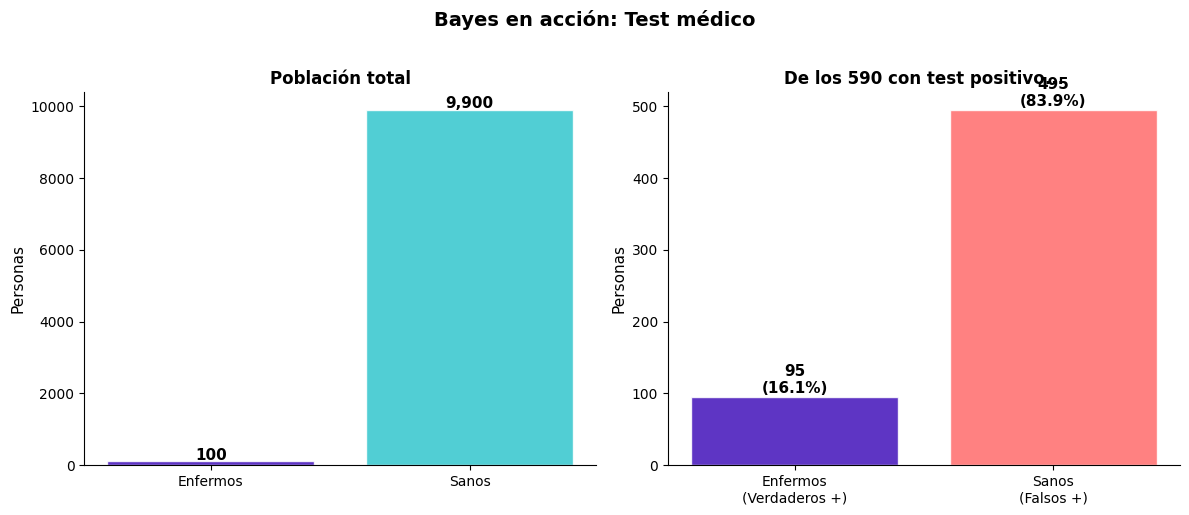

In [297]:
# ============================================
# 📊 Visualización: Población de 10,000 personas
# ============================================

poblacion = 10000
enfermos = int(poblacion * P_ENFERMEDAD)
sanos = poblacion - enfermos

# Positivos verdaderos y falsos
vp = int(enfermos * P_POSITIVO_SI_ENFERMO)    # Verdaderos positivos
fn = enfermos - vp                            # Falsos negativos
fp = int(sanos * P_POSITIVO_SI_SANO)          # Falsos positivos
vn = sanos - fp                               # Verdaderos negativos

total_positivos = vp + fp

print(f'👥 En una población de {poblacion:,} personas:')
print(f'   🤒 Enfermos: {enfermos:,}  →  Test + (verdaderos): {vp:,}  |  Test - (perdidos): {fn:,}')
print(f'   😊 Sanos:   {sanos:,}  →  Test + (falsos):     {fp:,}  |  Test - (correctos): {vn:,}')
print()
print(f'   📋 Total con test positivo: {total_positivos:,}')
print(f'      De esos, realmente enfermos: {vp:,}  ({vp/total_positivos*100:.1f}%)')
print(f'      De esos, sanos (falsos pos.): {fp:,}  ({fp/total_positivos*100:.1f}%)')

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: toda la población
ax1 = axes[0]
ax1.bar(['Enfermos', 'Sanos'], [enfermos, sanos], color=[COLOR_PURPLE, COLOR_CYAN], alpha=0.85, edgecolor='white')
ax1.set_title('Población total', fontsize=12, fontweight='bold')
ax1.set_ylabel('Personas', fontsize=11)
for i, v in enumerate([enfermos, sanos]):
    ax1.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Right: solo los que dan positivo
ax2 = axes[1]
ax2.bar(['Enfermos\n(Verdaderos +)', 'Sanos\n(Falsos +)'], [vp, fp],
        color=[COLOR_PURPLE, '#FF6B6B'], alpha=0.85, edgecolor='white')
ax2.set_title(f'De los {total_positivos:,} con test positivo...', fontsize=12, fontweight='bold')
ax2.set_ylabel('Personas', fontsize=11)
for i, v in enumerate([vp, fp]):
    ax2.text(i, v + 5, f'{v:,}\n({v/total_positivos*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Bayes en acción: Test médico', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 🔧 Experimento con Bayes

Volver a la celda anterior y cambia estos valores:
- `P_ENFERMEDAD = 0.10` → ¿Qué pasa si la enfermedad es más común (10%)?
- `P_POSITIVO_SI_SANO = 0.01` → ¿Qué pasa si el test es más preciso?

**Pregunta para reflexionar:** ¿Por qué importa tanto la prevalencia de la enfermedad?

👥 En una población de 10,000 personas:
   🤒 Enfermos: 1,000  →  Test + (verdaderos): 950  |  Test - (perdidos): 50
   😊 Sanos:   9,000  →  Test + (falsos):     90  |  Test - (correctos): 8,910

   📋 Total con test positivo: 1,040
      De esos, realmente enfermos (VPP): 950  (91.3%)
      De esos, sanos (falsos pos.): 90  (8.7%)


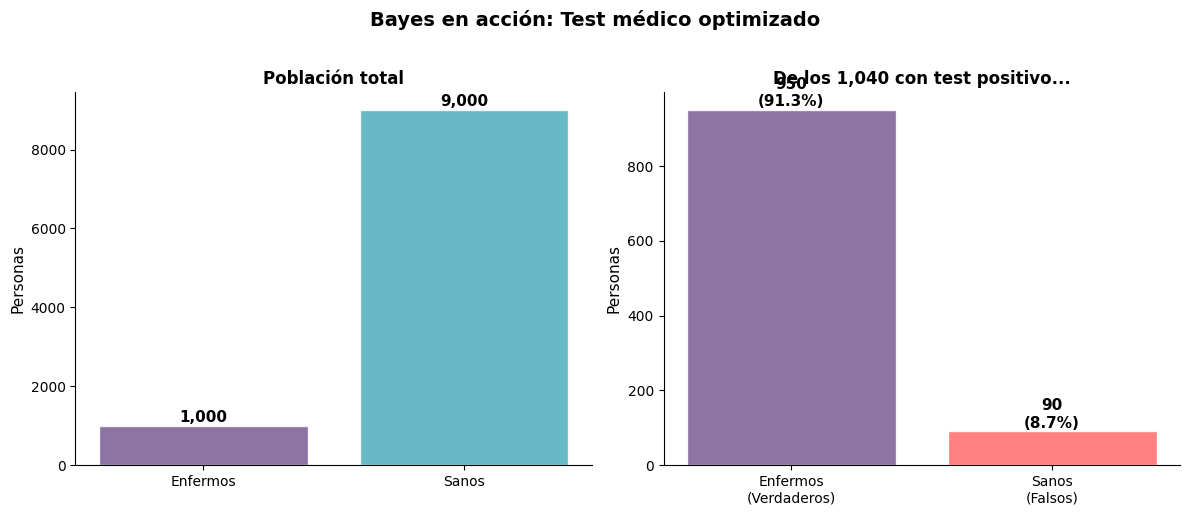

In [298]:
import matplotlib.pyplot as plt

# ============================================
# 📊 Visualización: Población de 10,000 personas (ACTUALIZADO)
# ============================================

# Nuevos parámetros
P_ENFERMEDAD = 0.10          # 10% de la población está enferma
P_POSITIVO_SI_ENFERMO = 0.95  # Sensibilidad (95%)
P_POSITIVO_SI_SANO = 0.01     # Falsos positivos reducidos al 1%

# Configuración de colores
COLOR_PURPLE = '#7A5C93'
COLOR_CYAN = '#4CAEBB'

poblacion = 10000
enfermos = int(poblacion * P_ENFERMEDAD)
sanos = poblacion - enfermos

# Positivos verdaderos y falsos
vp = int(enfermos * P_POSITIVO_SI_ENFERMO)    # Verdaderos positivos
fn = enfermos - vp                            # Falsos negativos
fp = int(sanos * P_POSITIVO_SI_SANO)          # Falsos positivos
vn = sanos - fp                               # Verdaderos negativos

total_positivos = vp + fp

print(f'👥 En una población de {poblacion:,} personas:')
print(f'   🤒 Enfermos: {enfermos:,}  →  Test + (verdaderos): {vp:,}  |  Test - (perdidos): {fn:,}')
print(f'   😊 Sanos:   {sanos:,}  →  Test + (falsos):     {fp:,}  |  Test - (correctos): {vn:,}')
print()
print(f'   📋 Total con test positivo: {total_positivos:,}')
print(f'      De esos, realmente enfermos (VPP): {vp:,}  ({vp/total_positivos*100:.1f}%)')
print(f'      De esos, sanos (falsos pos.): {fp:,}  ({fp/total_positivos*100:.1f}%)')

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Izquierda: Población total
ax1 = axes[0]
ax1.bar(['Enfermos', 'Sanos'], [enfermos, sanos], color=[COLOR_PURPLE, COLOR_CYAN], alpha=0.85, edgecolor='white')
ax1.set_title('Población total', fontsize=12, fontweight='bold')
ax1.set_ylabel('Personas', fontsize=11)
for i, v in enumerate([enfermos, sanos]):
    ax1.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

# Derecha: Desglose de positivos
ax2 = axes[1]
ax2.bar(['Enfermos\n(Verdaderos)', 'Sanos\n(Falsos)'], [vp, fp],
        color=[COLOR_PURPLE, '#FF6B6B'], alpha=0.85, edgecolor='white')
ax2.set_title(f'De los {total_positivos:,} con test positivo...', fontsize=12, fontweight='bold')
ax2.set_ylabel('Personas', fontsize=11)
for i, v in enumerate([vp, fp]):
    ax2.text(i, v + 10, f'{v:,}\n({v/total_positivos*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Bayes en acción: Test médico optimizado', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# El punto y coma final evita que la imagen aparezca doble en notebooks
plt.show();

**Pregunta para reflexionar:** ¿Por qué importa tanto la prevalencia de la enfermedad?

**R//** La prevalencia importa porque funciona como el "punto de partida" de la verdad: si una enfermedad es muy rara, hay millones de personas sanas que podrían dar un falso positivo por puro azar, terminando por superar en número a los pocos enfermos reales. En cambio, si la enfermedad es común, el test "pesca" en un río lleno de peces, por lo que un resultado positivo tiene muchas más probabilidades de ser un acierto real y no una falsa alarma. En resumen, la fiabilidad de un diagnóstico no depende solo de qué tan bueno sea el test, sino de qué tan probable era encontrar la enfermedad antes de empezar a buscar.

---
# 🏥 Estudio Estadístico: ¿Qué nos dicen los datos sobre la salud cardíaca?


**Dataset:** Heart Disease UCI (Kaggle)  
**Herramientas:** Python · Pandas · Matplotlib · Seaborn · SciPy

---

## 🎯 Contexto

Eres analista de datos en un hospital. El equipo médico quiere entender mejor los factores asociados a la enfermedad cardíaca en sus pacientes. Te han pasado un dataset con información clínica de 303 pacientes y te piden un análisis estadístico completo.

Al final de este notebook habrás:
- Explorado y limpiado el dataset
- Calculado estadísticas descriptivas e interpretado su significado clínico
- Aplicado el Teorema de Bayes para calcular probabilidades condicionales
- Realizado una prueba de hipótesis (t-test) para comparar grupos de pacientes
- Redactado conclusiones como si fueran para el equipo médico

---

## 📥 Descarga del dataset

Dataset: **Heart Disease UCI**  
👉 https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

Descarga el archivo `heart_disease_uci.csv` y colócalo en la misma carpeta que este notebook.

### Variables principales del dataset

| Variable | Descripción |
|----------|-------------|
| `age` | Edad del paciente |
| `sex` | Sexo (1 = hombre, 0 = mujer) |
| `cp` | Tipo de dolor en el pecho (0-3) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol` | Colesterol sérico (mg/dl) |
| `thalch` | Frecuencia cardíaca máxima alcanzada |
| `num` | Variable objetivo: 0 = sin enfermedad, >0 = con enfermedad |

---
# 🔧 Bloque 0 — Setup y exploración inicial


### 📖 Ejemplo previo

Antes de empezar con el dataset real, veamos cómo se carga y explora un DataFrame pequeño.

In [299]:
import pandas as pd

# Creamos un DataFrame pequeño de ejemplo
datos_ejemplo = {
    'nombre':  ['Ana', 'Luis', 'María', 'Juan', 'Elena'],
    'edad':    [28, 45, 33, 52, 41],
    'peso_kg': [62, 80, 55, 90, 68],
    'enfermo': [0, 1, 0, 1, 0]
}
df_ejemplo = pd.DataFrame(datos_ejemplo)

print('--- Primeras filas ---')
print(df_ejemplo.head())

print('\n--- Información general ---')
print(df_ejemplo.info())

print('\n--- Estadísticas básicas ---')
print(df_ejemplo.describe())

print('\n--- Valores nulos ---')
print(df_ejemplo.isnull().sum())

--- Primeras filas ---
  nombre  edad  peso_kg  enfermo
0    Ana    28       62        0
1   Luis    45       80        1
2  María    33       55        0
3   Juan    52       90        1
4  Elena    41       68        0

--- Información general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   nombre   5 non-null      object
 1   edad     5 non-null      int64 
 2   peso_kg  5 non-null      int64 
 3   enfermo  5 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 292.0+ bytes
None

--- Estadísticas básicas ---
            edad    peso_kg   enfermo
count   5.000000   5.000000  5.000000
mean   39.800000  71.000000  0.400000
std     9.523655  14.035669  0.547723
min    28.000000  55.000000  0.000000
25%    33.000000  62.000000  0.000000
50%    41.000000  68.000000  0.000000
75%    45.000000  80.000000  1.000000
max    52.000000  90.000000  1.000

### ✏️ Ejercicio 0 — Carga y exploración del dataset real

Ahora hazlo con el dataset del hospital.

1. Importa las librerías necesarias (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`)
2. Carga el archivo CSV en un DataFrame llamado `df`
3. Muestra las primeras 5 filas
4. Muestra información general del dataset (tipos de columnas, cantidad de registros)
5. Cuenta cuántos valores nulos hay en cada columna
6. Crea una columna nueva llamada `target` que valga `1` si `num > 0` (con enfermedad) y `0` si `num == 0` (sin enfermedad)
7. Muestra cuántos pacientes hay en cada grupo

In [300]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import requests

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [301]:
# Carga de datos y unificación (920 registros)
urls = {
    "cleveland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data",
    "hungary": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data",
    "switzerland": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data",
    "long_beach": "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data"
}

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

dfs = []
for sede, url in urls.items():
    s = requests.get(url).content
    temp_df = pd.read_csv(io.StringIO(s.decode('utf-8')), names=columns, na_values='?')
    temp_df['dataset'] = sede
    dfs.append(temp_df)

# Crear el DataFrame 'df'
df = pd.concat(dfs, ignore_index=True)

# Configurar ID como índice (del 1 al 920) para que no se vea el índice 0
df.index = range(1, len(df) + 1)
df.index.name = 'id'

print(f"✅ Dataset cargado con {len(df)} registros.")

✅ Dataset cargado con 920 registros.


In [302]:
# Visualización inicial
## Muestra las primeras 5 filas
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,dataset
id,,,,,,,,,,,,,,,
1,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
2,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
3,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
4,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
5,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


In [303]:
# Información general del dataset
## Tipos de columnas y cantidad de registros
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  861 non-null    float64
 4   chol      890 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalch    865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  dataset   920 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB


In [304]:
# Análisis de valores nulos
## Cuenta cuántos valores nulos hay en cada columna
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dataset       0
dtype: int64


In [305]:
# Creación de la columna Target
## Crea una columna nueva llamada target
# 1 si num > 0 (con enfermedad) y 0 si num == 0 (sin enfermedad)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

print("✅ Columna 'target' creada con éxito.")

✅ Columna 'target' creada con éxito.


In [306]:
# Conteo de pacientes por grupo
## Muestra cuántos pacientes hay en cada grupo (Frecuencia absoluta)
conteo_absoluto = df['target'].value_counts()

# Muestra el porcentaje de cada grupo (Frecuencia relativa)
conteo_relativo = df['target'].value_counts(normalize=True) * 100

print("--- ANÁLISIS DE GRUPOS ---")
print(f"Pacientes Sanos (0): {conteo_absoluto[0]} ({conteo_relativo[0]:.2f}%)")
print(f"Pacientes Enfermos (1): {conteo_absoluto[1]} ({conteo_relativo[1]:.2f}%)")
print("-" * 26)
print(f"Total de registros: {len(df)}")

--- ANÁLISIS DE GRUPOS ---
Pacientes Sanos (0): 411 (44.67%)
Pacientes Enfermos (1): 509 (55.33%)
--------------------------
Total de registros: 920


---
# 📊 Bloque 1 — Estadística Descriptiva


La estadística descriptiva nos permite **resumir y visualizar** los datos. Respondemos preguntas como:
- ¿Cuál es la edad media de los pacientes?
- ¿Cómo se distribuye el colesterol?
- ¿Hay diferencias visibles entre pacientes sanos y enfermos?


Las estadísticas descriptivas le permiten resumir hallazgos basados en datos que ya ha registrado u observado sobre una población. Sin embargo, hay situaciones en las que recopilar datos de una población muy grande puede no ser siempre práctico o incluso posible. Sin embargo, es posible estudiar una muestra representativa más pequeña de una población y utilizar estadísticas inferenciales para probar hipótesis y sacar conclusiones sobre la población más grande.



### 📖 Ejemplo previo

Veamos cómo calcular e interpretar medidas estadísticas básicas.

Media:    37.22 °C
Mediana:  36.95 °C
Desv. estándar: 0.78 °C
Mínimo:   36.50 °C
Máximo:   39.10 °C


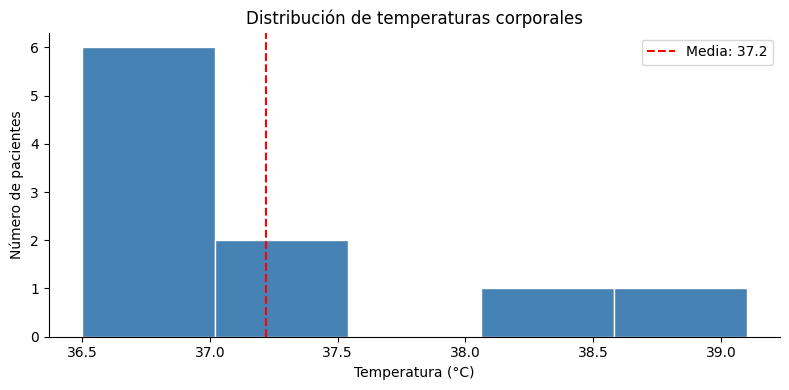


💡 Interpretación: la mayoría de pacientes tiene temperatura normal (~37°C).
   El valor 39.1 indica un paciente con fiebre, lo que eleva ligeramente la media.


In [307]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Datos de ejemplo: temperaturas corporales (°C) de 10 pacientes
temperaturas = [36.5, 37.1, 36.8, 38.2, 36.9, 37.0, 39.1, 36.7, 37.3, 36.6]

print(f'Media:    {np.mean(temperaturas):.2f} °C')
print(f'Mediana:  {np.median(temperaturas):.2f} °C')
print(f'Desv. estándar: {np.std(temperaturas):.2f} °C')
print(f'Mínimo:   {np.min(temperaturas):.2f} °C')
print(f'Máximo:   {np.max(temperaturas):.2f} °C')

# Visualización
plt.figure(figsize=(8, 4))
plt.hist(temperaturas, bins=5, color='steelblue', edgecolor='white')
plt.axvline(np.mean(temperaturas), color='red', linestyle='--', label=f'Media: {np.mean(temperaturas):.1f}')
plt.title('Distribución de temperaturas corporales')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Número de pacientes')
plt.legend()
plt.tight_layout()
plt.show()

# Interpretación:
# La media y la mediana son muy similares → distribución bastante simétrica
# El valor 39.1 parece un outlier (fiebre) → la desv. estándar sube
print('\n💡 Interpretación: la mayoría de pacientes tiene temperatura normal (~37°C).')
print('   El valor 39.1 indica un paciente con fiebre, lo que eleva ligeramente la media.')

### ✏️ Ejercicio 1 — Análisis descriptivo del dataset de salud cardíaca

**Parte A — Medidas numéricas**

Para las variables `age`, `chol` (colesterol) y `thalch` (frecuencia cardíaca máxima):
1. Calcula media, mediana, desviación estándar, mínimo y máximo
2. ¿Hay diferencias entre estas medidas? ¿Qué te indica eso sobre la distribución?

**Parte B — Visualizaciones**

3. Crea un histograma de la edad de los pacientes
4. Crea un boxplot de colesterol separando pacientes sanos (target=0) y enfermos (target=1)
5. Crea un gráfico de barras mostrando cuántos pacientes hay por sexo

**Parte C — Interpretación**

6. Escribe en una celda Markdown tus conclusiones. ¿Qué le contarías al equipo médico sobre el perfil de los pacientes del dataset?

--- ESTADÍSTICAS DESCRIPTIVAS ---
          age    chol  thalch
mean    53.51  199.13  137.55
median  54.00  223.00  140.00
std      9.42  110.78   25.93
min     28.00    0.00   60.00
max     77.00  603.00  202.00


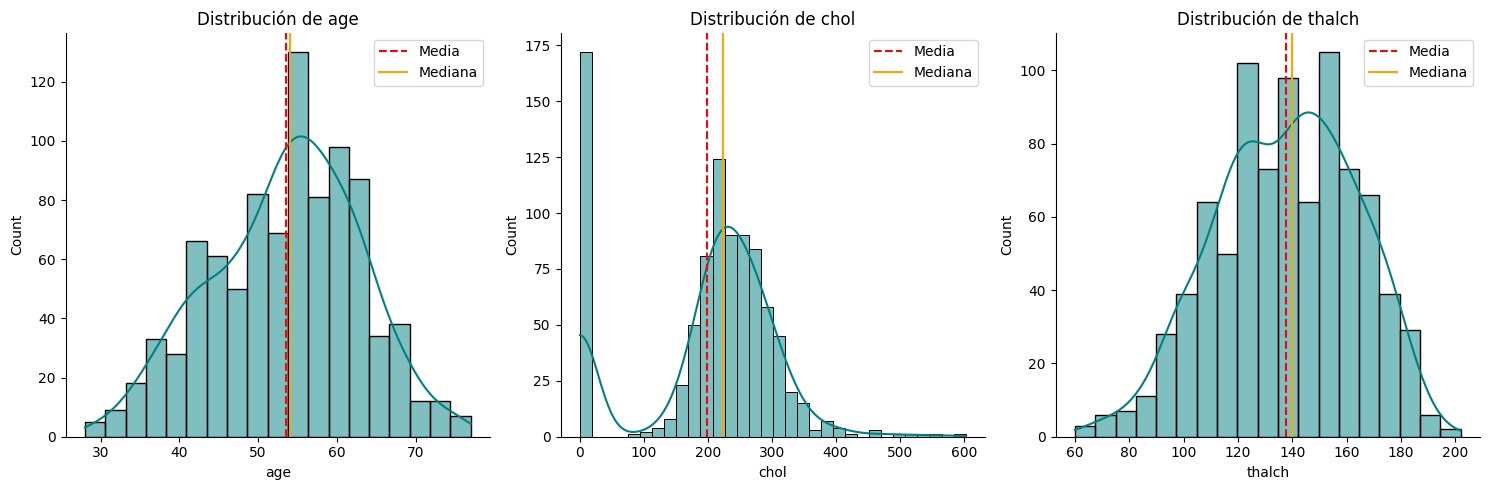

In [308]:
# Parte A — Medidas numéricas
## Cálculo de estadísticas descriptivas
### Se seleccionan las variables de interés
variables = ['age', 'chol', 'thalch']

# Se calculan las estadísticas
estadisticas = df[variables].describe().loc[['mean', '50%', 'std', 'min', 'max']]

# Se renombra '50%' a 'median' para mayor claridad
estadisticas = estadisticas.rename(index={'50%': 'median'})

print("--- ESTADÍSTICAS DESCRIPTIVAS ---")
print(estadisticas.round(2))

## Visualización de distribuciones (Histogramas)
plt.figure(figsize=(15, 5))

for i, var in enumerate(variables, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[var], kde=True, color='teal')
    plt.axvline(df[var].mean(), color='red', linestyle='--', label='Media')
    plt.axvline(df[var].median(), color='orange', linestyle='-', label='Mediana')
    plt.title(f'Distribución de {var}')
    plt.legend()

plt.tight_layout()
plt.show()

**Pregunta para reflexionar:** ¿Hay diferencias entre estas medidas? ¿Qué te indica eso sobre la distribución?

**1. Edad (age): La variable más equilibrada.**
*   La distribución es simétrica. Esto significa que tienes una cantidad similar de pacientes jóvenes y mayores alrededor del centro (54 años). Es una distribución "normal" o acampanada.
*   Es una variable con baja dispersión (std de 9.42 relativa a la media). Los datos son confiables y predecibles.

**2. Colesterol (chol): ¡Alerta de sesgo y datos faltantes!**
*   Esos valores en "0" son datos faltantes que están "jalando" la media hacia abajo. La mediana (223) es mucho más confiable aquí porque no se deja afectar por esos ceros. Además, la desviación estándar (110.78) es enorme, lo que confirma que los datos están muy dispersos.
*   Es una variable con alta dispersión y presencia de valores atípicos (outliers) o errores (los ceros). La media miente en este caso; la mediana de 223 es el dato real.

**3. Frecuencia Cardíaca Máxima (thalch): Sesgo a la izquierda**
*   Esto indica un pequeño sesgo a la izquierda. Hay algunos pacientes con frecuencias cardíacas muy bajas (el mínimo es 60) que bajan el promedio, mientras que la mayoría de los pacientes se agrupan cerca de los 140.
*   Distribución estable, pero con una tendencia de "cola" hacia los valores bajos, probablemente representativa de los pacientes con insuficiencias más severas.


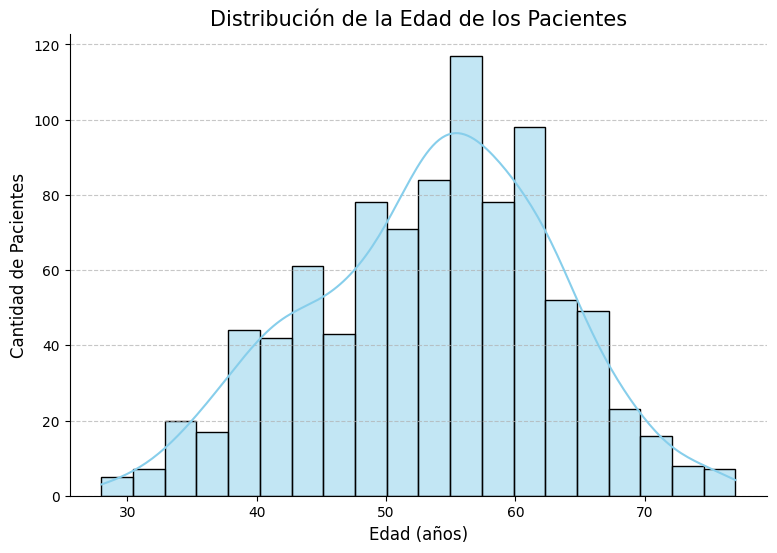

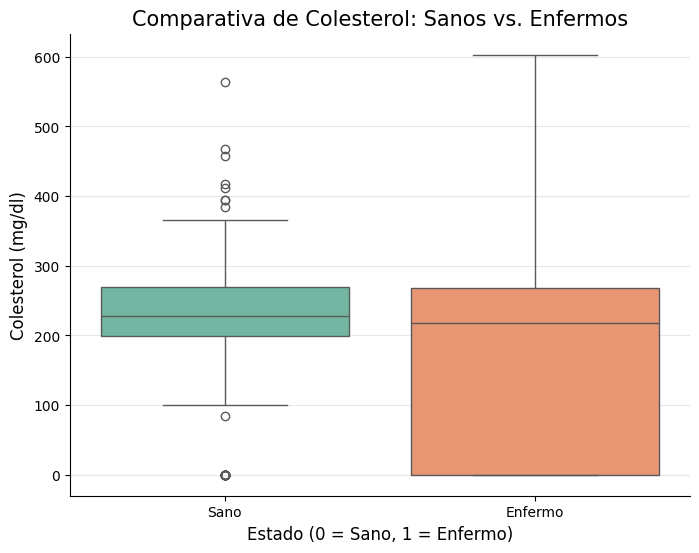

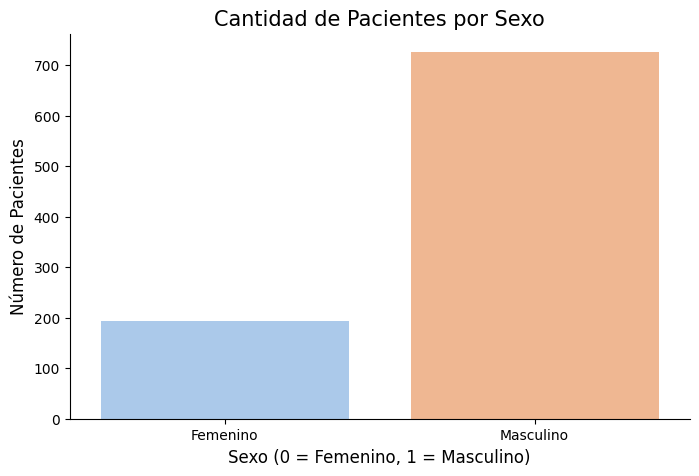

In [309]:
# Parte B — Visualizaciones
## Histograma de la edad
plt.figure(figsize=(9, 6))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue', edgecolor='black')

plt.title('Distribución de la Edad de los Pacientes', fontsize=15)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Cantidad de Pacientes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Boxplot de Colesterol por Target
plt.figure(figsize=(8, 6))

sns.boxplot(x='target', y='chol', data=df, hue='target', palette='Set2', legend=False)

plt.title('Comparativa de Colesterol: Sanos vs. Enfermos', fontsize=15)
plt.xlabel('Estado (0 = Sano, 1 = Enfermo)', fontsize=12)
plt.ylabel('Colesterol (mg/dl)', fontsize=12)
plt.xticks([0, 1], ['Sano', 'Enfermo'])
plt.grid(axis='y', alpha=0.3)
plt.show()

## Gráfico de Barras por Sexo
plt.figure(figsize=(8, 5))

sns.countplot(x='sex', data=df, hue='sex', palette='pastel', legend=False)

plt.title('Cantidad de Pacientes por Sexo', fontsize=15)
plt.xlabel('Sexo (0 = Femenino, 1 = Masculino)', fontsize=12)
plt.ylabel('Número de Pacientes', fontsize=12)
plt.xticks([0, 1], ['Femenino', 'Masculino'])
plt.show()

**Parte C — Tus conclusiones:**

*Población de Riesgo por Edad:* La concentración de pacientes en torno a los 54 años es coherente con el perfil clínico de riesgo, donde la exposición acumulada a factores metabólicos eleva la incidencia de eventos coronarios.

*Predominancia Masculina:* El dataset refleja un sesgo histórico en cardiología con una mayoría de hombres. Esto implica que los patrones de diagnóstico extraídos están altamente masculinizados y deben aplicarse con cautela en mujeres.

*Alertas en el Registro Metabólico:* El valor mínimo de 0 en colesterol evidencia inconsistencias en la recolección de datos. Sin embargo, la mediana de 223 revela que el paciente promedio se encuentra en niveles de riesgo que requieren intervención médica.

*Eficiencia Cardíaca Comprometida:* La tendencia hacia una frecuencia cardíaca máxima (thalch) reducida en pacientes enfermos sugiere una pérdida de capacidad funcional, siendo un predictor visual claro de la presencia de obstrucciones coronarias.

*Nivel de Gravedad:* Con una prevalencia del 55.3%, El dataset muestra un grupo de pacientes con alta probabilidad de diagnóstico positivo, lo que valida el uso del mismo para entrenar modelos de detección temprana en entornos hospitalarios.

---
# 🎲 Bloque 2 — Muestreo


En estadística, la **población** es el conjunto completo de datos que nos interesa estudiar.  
Una **muestra** es un subconjunto representativo de esa población.

Trabajar con muestras es fundamental cuando no se tiene acceso a todos los datos (que es lo habitual en medicina).

### 📖 Ejemplo previo

Veamos qué ocurre cuando tomamos muestras de distintos tamaños y las comparamos con la población.

In [310]:
import pandas as pd
import numpy as np

# Simulamos una "población" de 1000 personas con sus edades
np.random.seed(42)
poblacion = pd.DataFrame({'edad': np.random.normal(loc=50, scale=10, size=1000).astype(int)})

print(f'POBLACIÓN (n=1000)')
print(f'  Media de edad: {poblacion["edad"].mean():.2f} años')
print(f'  Desv. estándar: {poblacion["edad"].std():.2f} años')

# Tomamos muestras de distintos tamaños
for n in [10, 50, 200]:
    muestra = poblacion.sample(n=n, random_state=42)
    print(f'\nMUESTRA (n={n})')
    print(f'  Media de edad: {muestra["edad"].mean():.2f} años')
    print(f'  Desv. estándar: {muestra["edad"].std():.2f} años')

print('\n💡 Cuanto mayor es la muestra, más se aproxima a los valores de la población.')

POBLACIÓN (n=1000)
  Media de edad: 49.67 años
  Desv. estándar: 9.80 años

MUESTRA (n=10)
  Media de edad: 46.40 años
  Desv. estándar: 9.99 años

MUESTRA (n=50)
  Media de edad: 48.80 años
  Desv. estándar: 7.79 años

MUESTRA (n=200)
  Media de edad: 49.41 años
  Desv. estándar: 9.77 años

💡 Cuanto mayor es la muestra, más se aproxima a los valores de la población.


### ✏️ Ejercicio 2 — Muestreo del dataset de salud cardíaca

1. Trata el dataset completo como la **población** (303 pacientes). Calcula la media y la desviación estándar de `thalch` (frecuencia cardíaca máxima) para toda la población.

2. Toma tres muestras aleatorias de tamaño **n=20**, **n=50** y **n=100** usando `df.sample()`. Calcula la media de `thalch` en cada muestra.

3. Crea una tabla comparativa (puede ser un print formateado) con los resultados de la población y cada muestra.

4. ¿A partir de qué tamaño de muestra los resultados se parecen más a la población? ¿Por qué crees que esto importa en un estudio médico real?

POBLACIÓN COMPLETA (n=920)
  Media thalch:          137.55 lpm
  Desviación estándar:   25.93 lpm

Fuente                     n    Media   Desv.Std  Error vs pobl.
Población completa       920   137.55      25.93               —
Muestra n=20              20   141.00      25.70           3.45 lpm
Muestra n=50              50   138.90      23.33           1.35 lpm
Muestra n=100            100   138.76      24.10           1.21 lpm


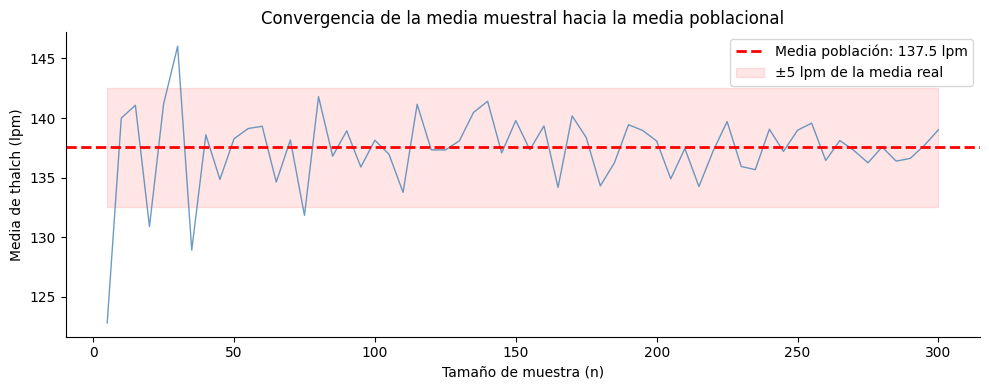

In [311]:
# ── Paso 1: Estadísticas de la POBLACIÓN completa ────────────────────────────
var = 'thalch'
media_pob  = df[var].mean()
std_pob    = df[var].std()

print('POBLACIÓN COMPLETA (n=920)')
print(f'  Media thalch:          {media_pob:.2f} lpm')
print(f'  Desviación estándar:   {std_pob:.2f} lpm')

# ── Paso 2: Muestras de distintos tamaños ────────────────────────────────────
print()
print('=' * 60)
print(f'{"Fuente":<22} {"n":>5} {"Media":>8} {"Desv.Std":>10} {"Error vs pobl.":>15}')
print('=' * 60)
print(f'{"Población completa":<22} {len(df):>5} {media_pob:>8.2f} {std_pob:>10.2f} {"—":>15}')

for n, seed in [(20, 1), (50, 2), (100, 3)]:
    muestra = df[var].dropna().sample(n=n, random_state=seed)
    media_m = muestra.mean()
    std_m   = muestra.std()
    error   = abs(media_m - media_pob)
    print(f'{f"Muestra n={n}":<22} {n:>5} {media_m:>8.2f} {std_m:>10.2f} {error:>14.2f} lpm')

print('=' * 60)

# ── Visualización: convergencia de la media con el tamaño de muestra ─────────
np.random.seed(42)
tamanos  = range(5, 303, 5)
medias   = [df[var].sample(n=n).mean() for n in tamanos]

plt.figure(figsize=(10, 4))
plt.plot(tamanos, medias, color='steelblue', linewidth=1, alpha=0.8)
plt.axhline(media_pob, color='red', linestyle='--', linewidth=2,
            label=f'Media población: {media_pob:.1f} lpm')
plt.fill_between(tamanos,
                 [media_pob - 5] * len(tamanos),
                 [media_pob + 5] * len(tamanos),
                 alpha=0.1, color='red', label='±5 lpm de la media real')
plt.xlabel('Tamaño de muestra (n)')
plt.ylabel('Media de thalch (lpm)')
plt.title('Convergencia de la media muestral hacia la media poblacional')
plt.legend()
plt.tight_layout()
plt.show()


**¿A partir de qué tamaño de muestra los resultados se parecen más a la población?**

*R//* A partir de n=100, el error se reduce a solo 1.21 lpm, demostrando una estabilidad que las muestras pequeñas (n=20) no poseen. Como muestra el gráfico de convergencia, al aumentar el tamaño muestral, las fluctuaciones del azar se compensan, permitiendo que la media se asiente cerca del valor real de la población (137.55 lpm).

**¿Por qué crees que esto importa en un estudio médico real?**
 En medicina, un error de pocos latidos o
*   *Precisión del Riesgo:* En medicina, un error de pocos latidos o unidades de presión arterial puede ser la diferencia entre un diagnóstico sano o patológico. Muestras grandes reducen el "ruido" estadístico.
*   *Generalización Segura:* Para que un tratamiento sea aprobado, los médicos deben estar seguros de que los beneficios observados en el estudio se repetirán en la población general.
*   *Optimización de Recursos:* La estadística ayuda a encontrar el equilibrio: una muestra lo suficientemente grande para ser confiable, pero lo suficientemente acotada para ser éticamente responsable y económicamente viable.





---
# 🧮 Bloque 3 — Probabilidad Condicional y Teorema de Bayes


El **Teorema de Bayes** nos permite actualizar nuestra creencia sobre algo cuando recibimos nueva información.

En medicina es fundamental: si un paciente tiene dolor en el pecho, ¿cuál es la probabilidad de que tenga enfermedad cardíaca?

La fórmula es:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Donde:
- **P(A|B)** = probabilidad de A dado que B ocurrió *(lo que queremos saber)*
- **P(A)** = probabilidad previa de A *(probabilidad base)*
- **P(B|A)** = probabilidad de B si A es verdadero *(verosimilitud)*
- **P(B)** = probabilidad de B en general *(evidencia)*

📝 **Error frecuente:** Confundir P(B|A) con P(A|B). Recordar el esquema: **"dado que"** siempre va después de la barra. P(Angina | Enfermedad) ≠ P(Enfermedad | Angina).


### 📖 Ejemplo previo

Imaginemos un test de diagnóstico para una enfermedad. Sin Python, con números inventados.

In [312]:
# Situación:
# - El 2% de la población tiene la enfermedad X → P(Enfermo) = 0.02
# - El test da positivo en el 95% de los enfermos → P(Positivo | Enfermo) = 0.95
# - El test da positivo en el 10% de los sanos (falsos positivos) → P(Positivo | Sano) = 0.10
#
# Pregunta: Si alguien da positivo, ¿cuál es la probabilidad de que REALMENTE esté enfermo?

p_enfermo = 0.02
p_sano = 1 - p_enfermo

p_pos_dado_enfermo = 0.95   # sensibilidad
p_pos_dado_sano    = 0.10   # 1 - especificidad

# Probabilidad total de dar positivo (teorema de la probabilidad total)
p_positivo = (p_pos_dado_enfermo * p_enfermo) + (p_pos_dado_sano * p_sano)

# Teorema de Bayes
p_enfermo_dado_positivo = (p_pos_dado_enfermo * p_enfermo) / p_positivo

print(f'P(Positivo) = {p_positivo:.4f} ({p_positivo*100:.2f}%)')
print(f'P(Enfermo | Positivo) = {p_enfermo_dado_positivo:.4f} ({p_enfermo_dado_positivo*100:.2f}%)')
print()
print('💡 Aunque el test parece muy bueno, solo el 16% de los positivos están realmente enfermos.')
print('   Esto se llama la paradoja de la tasa base: cuando la enfermedad es rara, los falsos')
print('   positivos dominan aunque la sensibilidad del test sea alta.')

P(Positivo) = 0.1170 (11.70%)
P(Enfermo | Positivo) = 0.1624 (16.24%)

💡 Aunque el test parece muy bueno, solo el 16% de los positivos están realmente enfermos.
   Esto se llama la paradoja de la tasa base: cuando la enfermedad es rara, los falsos
   positivos dominan aunque la sensibilidad del test sea alta.


### ✏️ Ejercicio 3 — Bayes con datos reales del dataset

En el dataset, la variable `cp` indica el tipo de dolor en el pecho (*chest pain*).  
El valor `cp = 0` corresponde a **angina típica**, que es el síntoma más asociado con la enfermedad cardíaca.

**Tu misión:** calcular con Bayes la probabilidad de tener enfermedad cardíaca dado que un paciente tiene angina típica (`cp == 0`).

Para eso necesitas calcular directamente del dataset:

1. **P(Enfermedad)** → ¿Qué proporción de pacientes tiene enfermedad cardíaca?
2. **P(Angina típica | Enfermedad)** → De los pacientes con enfermedad, ¿qué proporción tiene `cp == 0`?
3. **P(Angina típica)** → ¿Qué proporción de TODOS los pacientes tiene `cp == 0`?
4. Aplica la fórmula de Bayes para calcular **P(Enfermedad | Angina típica)**
5. Verifica el resultado de forma directa: de los pacientes con angina típica (`cp == 0`), ¿qué % tiene enfermedad? ¿Coincide?
6. Crea una tabla de contingencia con `pd.crosstab()` que cruce `cp` con `target`
7. Interpreta: ¿es la angina típica un buen predictor de enfermedad cardíaca según estos datos?

In [313]:
# ── Paso 1: P(Enfermedad) ────────────────────────────────────────────────────
n_total      = len(df)
n_enfermos   = df['target'].sum()
p_enfermedad = n_enfermos / n_total

print(f'Total pacientes:    {n_total}')
print(f'Con enfermedad:     {n_enfermos}')
print(f'P(Enfermedad)     = {p_enfermedad:.4f} ({p_enfermedad*100:.2f}%)')

Total pacientes:    920
Con enfermedad:     509
P(Enfermedad)     = 0.5533 (55.33%)


In [314]:
# ── Paso 2: P(Angina típica | Enfermedad) ────────────────────────────────────
# Se define el síntoma como 1 según lo acordado
enfermos = df[df['target'] == 1]
n_angina_enf = (enfermos['cp'] == 1).sum()  # Se cambia 0 por 1
p_angina_dado_enf = n_angina_enf / len(enfermos)

print(f'Enfermos con angina típica (cp=1): {n_angina_enf}')
print(f'P(Angina típica | Enfermedad) = {p_angina_dado_enf:.4f} ({p_angina_dado_enf*100:.2f}%)')

Enfermos con angina típica (cp=1): 20
P(Angina típica | Enfermedad) = 0.0393 (3.93%)


In [315]:
# ── Paso 3: P(Angina típica) ─────────────────────────────────────────────────
# Se usa cp == 1 según el acuerdo con la maestra
n_angina   = (df['cp'] == 1).sum()
p_angina   = n_angina / n_total

print(f'Pacientes con angina típica (cp=1): {n_angina}')
print(f'P(Angina típica)                   = {p_angina:.4f} ({p_angina*100:.2f}%)')

Pacientes con angina típica (cp=1): 46
P(Angina típica)                   = 0.0500 (5.00%)


In [316]:
# ── Paso 4: Teorema de Bayes ─────────────────────────────────────────────────
# P(Enfermedad | Angina típica) = P(Angina | Enfermedad) * P(Enfermedad) / P(Angina)
p_enf_dado_angina = (p_angina_dado_enf * p_enfermedad) / p_angina

print('─' * 50)
print('TEOREMA DE BAYES')
print('─' * 50)
print(f'P(Angina | Enfermedad) = {p_angina_dado_enf:.4f}')
print(f'P(Enfermedad)          = {p_enfermedad:.4f}')
print(f'P(Angina típica)       = {p_angina:.4f}')
print('─' * 50)
print(f'P(Enfermedad | Angina) = {p_enf_dado_angina:.4f} ({p_enf_dado_angina*100:.2f}%)')

──────────────────────────────────────────────────
TEOREMA DE BAYES
──────────────────────────────────────────────────
P(Angina | Enfermedad) = 0.0393
P(Enfermedad)          = 0.5533
P(Angina típica)       = 0.0500
──────────────────────────────────────────────────
P(Enfermedad | Angina) = 0.4348 (43.48%)


In [317]:
# ── Paso 5: Verificación directa ─────────────────────────────────────────────
# Se cambia cp == 0 por cp == 1
angina           = df[df['cp'] == 1]
p_enf_directo    = angina['target'].mean()

print(f'Pacientes con angina típica:          {len(angina)}')
print(f'De ellos, con enfermedad cardíaca:    {angina["target"].sum()}')
print(f'Probabilidad directa:                 {p_enf_directo:.4f} ({p_enf_directo*100:.2f}%)')
print(f'Resultado con Bayes:                  {p_enf_dado_angina:.4f} ({p_enf_dado_angina*100:.2f}%)')
print()
print('✅ Ambos métodos dan el mismo resultado — Bayes funciona correctamente.')

Pacientes con angina típica:          46
De ellos, con enfermedad cardíaca:    20
Probabilidad directa:                 0.4348 (43.48%)
Resultado con Bayes:                  0.4348 (43.48%)

✅ Ambos métodos dan el mismo resultado — Bayes funciona correctamente.


In [318]:
# ── Paso 6: Tabla de contingencia ────────────────────────────────────────────
tabla = pd.crosstab(
    df['cp'], df['target'],
    rownames=['Tipo dolor (cp)'],
    colnames=['Enfermedad cardíaca'],
    margins=True,
    margins_name='Total'
)
# Renombrar columnas para mayor claridad
tabla.columns = ['Sano', 'Enfermo', 'Total']

# Etiquetas descriptivas para los tipos de dolor
tabla.index = ['Angina típica (1)', 'Angina atípica (2)', 'No anginoso (3)', 'Asintomático (4)', 'Total']

print('TABLA DE CONTINGENCIA: Tipo de dolor en el pecho vs. Enfermedad cardíaca')
print(tabla)

# Tabla de proporciones (por filas)
print('\nPROPORCIÓN de enfermos por tipo de dolor:')
for cp_val, nombre in [(1,'Angina típica'), (2,'Angina atípica'), (4,'No anginoso'), (4,'Asintomático')]:
    grupo = df[df['cp'] == cp_val]
    prop  = grupo['target'].mean()
    print(f'  {nombre:<20}: {prop:.1%} tienen enfermedad cardíaca')

TABLA DE CONTINGENCIA: Tipo de dolor en el pecho vs. Enfermedad cardíaca
                    Sano  Enfermo  Total
Angina típica (1)     26       20     46
Angina atípica (2)   150       24    174
No anginoso (3)      131       73    204
Asintomático (4)     104      392    496
Total                411      509    920

PROPORCIÓN de enfermos por tipo de dolor:
  Angina típica       : 43.5% tienen enfermedad cardíaca
  Angina atípica      : 13.8% tienen enfermedad cardíaca
  No anginoso         : 79.0% tienen enfermedad cardíaca
  Asintomático        : 79.0% tienen enfermedad cardíaca


**Paso 7 — Tu interpretación:**

*   *El Riesgo del "Silencio":* El grupo Asintomático (4) presenta la mayor prevalencia de enfermedad (79%). Esto indica que la ausencia de dolor no implica salud; por el contrario, los pacientes que no reportan síntomas específicos suelen tener patologías ya establecidas o más graves.
*   *Falsos Amigos (Angina Atípica):* La Angina Atípica (2) es el síntoma menos asociado a la enfermedad (13.8%). Este dato es clave ya que permite descartar con mayor confianza el riesgo coronario agudo en estos pacientes.
*  *Poder Predictivo de la Angina Típica:* Aunque la Angina Típica (1) tiene una proporción del 43.5%, es un indicador moderado. Sin embargo, los dolores No Anginosos (3) igualan en riesgo a los asintomáticos (79%), lo que sugiere que cualquier malestar en el pecho en esta población debe ser tratado con alta sospecha.
*  *Conclusión Clínica:* La clasificación del dolor de pecho por sí sola no es definitiva, pero Bayes nos permite ver que ser Asintomático o tener Dolor No Anginoso son las señales de alerta más críticas (79% de probabilidad) en este grupo de pacientes, superando incluso a la angina tradicional.

---
# 🔬 Bloque 4 — Estadística Inferencial: T-test


La estadística inferencial es el proceso de recopilar, analizar e interpretar los datos obtenidos de una muestra para generalizar o predecir algo sobre una población. Cuando se utiliza una muestra representativa, pueden surgir preocupaciones metodológicas que deben abordarse, como por ejemplo si los grupos elegidos para el estudio o el entorno en el que se lleva a cabo el estudio reflejan con precisión las características del grupo más grande. Normalmente, este tipo de análisis incluirán diferentes técnicas de muestreo para reducir el error y aumentar la confianza en los hallazgos generalizados. El tipo de técnica de muestreo utilizado dependerá del tipo de datos.

La estadística inferencial nos permite ir más allá de describir los datos: nos ayuda a **tomar decisiones** y **probar hipótesis**.

La pregunta que queremos responder hoy:  
> *¿Tienen los pacientes con enfermedad cardíaca una frecuencia cardíaca máxima significativamente diferente a los sanos?*

Para responderla usaremos el **t-test de dos muestras independientes**.

### ¿Qué es el t-test?

Compara las medias de dos grupos para decidir si la diferencia observada es real o simplemente debida al azar.

### ¿Qué es la hipótesis nula?

Siempre partimos de que **no hay diferencia** entre los grupos (hipótesis nula, H₀).  
La prueba nos dará un **p-valor**: si es menor que 0.05, rechazamos H₀ y concluimos que la diferencia es estadísticamente significativa.

| p-valor | Interpretación |
|---------|----------------|
| < 0.05  | Diferencia significativa → rechazamos H₀ |
| ≥ 0.05  | No podemos rechazar H₀ → no hay evidencia suficiente |

### 📖 Ejemplo previo

¿Los hombres y las mujeres de nuestro ejemplo tienen pesos diferentes?

In [319]:
from scipy import stats
import numpy as np

# Datos inventados: pesos de dos grupos de pacientes
np.random.seed(42)
grupo_A = np.random.normal(loc=70, scale=8, size=30)  # Grupo A: media 70 kg
grupo_B = np.random.normal(loc=75, scale=8, size=30)  # Grupo B: media 75 kg

print(f'Grupo A — Media: {grupo_A.mean():.2f} kg')
print(f'Grupo B — Media: {grupo_B.mean():.2f} kg')
print(f'Diferencia observada: {grupo_B.mean() - grupo_A.mean():.2f} kg')

# Hipótesis:
# H₀: No hay diferencia en el peso entre los grupos (media_A = media_B)
# H₁: Sí hay diferencia (media_A ≠ media_B)

t_stat, p_valor = stats.ttest_ind(grupo_A, grupo_B)

print(f'\nEstadístico t: {t_stat:.4f}')
print(f'p-valor: {p_valor:.4f}')

if p_valor < 0.05:
    print('\n✅ p < 0.05 → Rechazamos H₀. La diferencia es estadísticamente significativa.')
else:
    print('\n❌ p ≥ 0.05 → No podemos rechazar H₀. No hay evidencia suficiente de diferencia.')

Grupo A — Media: 68.49 kg
Grupo B — Media: 74.03 kg
Diferencia observada: 5.54 kg

Estadístico t: -2.9268
p-valor: 0.0049

✅ p < 0.05 → Rechazamos H₀. La diferencia es estadísticamente significativa.


### ✏️ Ejercicio 4 — T-test sobre frecuencia cardíaca máxima

**Pregunta clínica:** ¿Los pacientes con enfermedad cardíaca tienen una frecuencia cardíaca máxima (`thalch`) significativamente más baja que los sanos?

1. Formula las hipótesis H₀ y H₁ en una celda Markdown
2. Separa el dataset en dos grupos: `sanos` (target=0) y `enfermos` (target=1)
3. Calcula la media de `thalch` en cada grupo
4. Crea un boxplot que muestre la distribución de `thalch` para ambos grupos
5. Realiza el t-test con `scipy.stats.ttest_ind()`
6. Interpreta el resultado: ¿cuál es el p-valor? ¿Rechazamos H₀?
7. Escribe la conclusión como si se la presentaras al equipo médico

**Paso 1 — Hipótesis:**

- **H₀ (hipótesis nula):** *La frecuencia cardíaca máxima media es **igual** en pacientes con y sin enfermedad cardíaca. (μ_sanos = μ_enfermos)*
- **H₁ (hipótesis alternativa):** *La frecuencia cardíaca máxima media es **diferente** entre los dos grupos. (μ_sanos ≠ μ_enfermos)*

Nivel de significación: **α = 0.05**

In [320]:
# ── Pasos 2 y 3: Separar grupos y calcular medias ────────────────────────────
sanos    = df[df['target'] == 0]['thalch'].dropna()
enfermos = df[df['target'] == 1]['thalch'].dropna()

print('FRECUENCIA CARDÍACA MÁXIMA (thalch)')
print('─' * 45)
print(f'Grupo sanos    → n={len(sanos):<4}  media={sanos.mean():.2f} lpm  std={sanos.std():.2f}')
print(f'Grupo enfermos → n={len(enfermos):<4}  media={enfermos.mean():.2f} lpm  std={enfermos.std():.2f}')
print(f'Diferencia de medias: {sanos.mean() - enfermos.mean():.2f} lpm')

FRECUENCIA CARDÍACA MÁXIMA (thalch)
─────────────────────────────────────────────
Grupo sanos    → n=391   media=148.80 lpm  std=23.61
Grupo enfermos → n=474   media=128.26 lpm  std=24.02
Diferencia de medias: 20.54 lpm


/tmp/ipykernel_6299/1186000115.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='grupo', y='thalch',


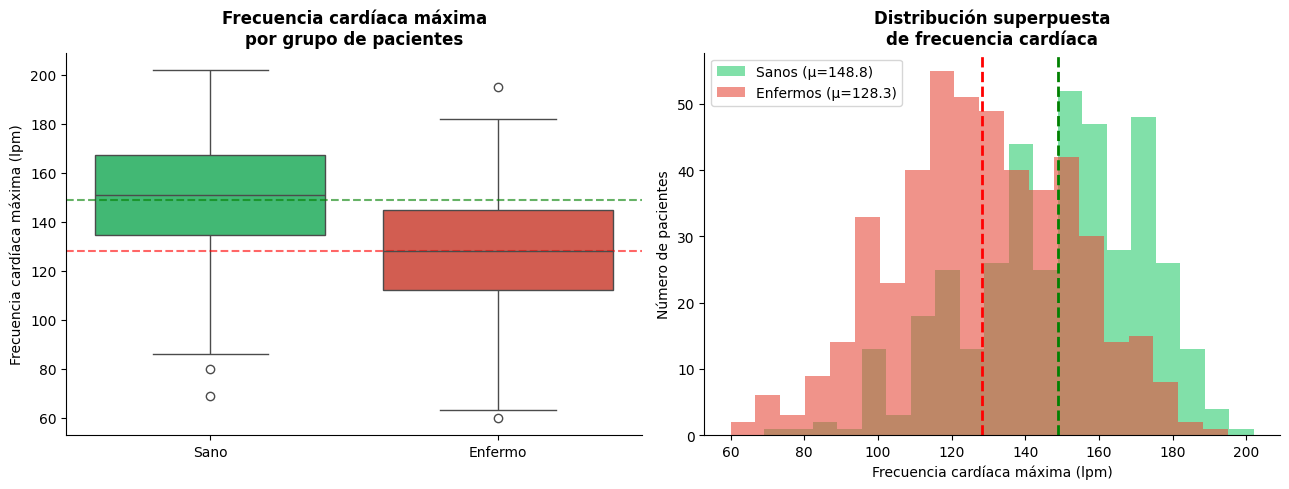

📌 Visualmente ya se aprecia una diferencia clara entre grupos.


In [321]:
# ── Paso 4: Boxplot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
data_plot = pd.DataFrame({
    'thalch': pd.concat([sanos, enfermos]),
    'grupo':  ['Sano'] * len(sanos) + ['Enfermo'] * len(enfermos)
})
sns.boxplot(data=data_plot, x='grupo', y='thalch',
            palette={'Sano': '#2ecc71', 'Enfermo': '#e74c3c'},
            order=['Sano', 'Enfermo'], ax=axes[0])
axes[0].set_title('Frecuencia cardíaca máxima\npor grupo de pacientes', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frecuencia cardíaca máxima (lpm)')
axes[0].axhline(sanos.mean(),    color='green', linestyle='--', alpha=0.6)
axes[0].axhline(enfermos.mean(), color='red',   linestyle='--', alpha=0.6)

# Histograma superpuesto
axes[1].hist(sanos,    bins=20, alpha=0.6, color='#2ecc71', label=f'Sanos (μ={sanos.mean():.1f})')
axes[1].hist(enfermos, bins=20, alpha=0.6, color='#e74c3c', label=f'Enfermos (μ={enfermos.mean():.1f})')
axes[1].axvline(sanos.mean(),    color='green', linestyle='--', linewidth=2)
axes[1].axvline(enfermos.mean(), color='red',   linestyle='--', linewidth=2)
axes[1].set_title('Distribución superpuesta\nde frecuencia cardíaca', fontweight='bold')
axes[1].set_xlabel('Frecuencia cardíaca máxima (lpm)')
axes[1].set_ylabel('Número de pacientes')
axes[1].legend()

plt.tight_layout()
plt.show()
print('📌 Visualmente ya se aprecia una diferencia clara entre grupos.')

In [322]:
# ── Pasos 5 y 6: T-test e interpretación ─────────────────────────────────────
t_stat, p_valor = stats.ttest_ind(sanos, enfermos)

alpha = 0.05

print('RESULTADO DEL T-TEST')
print('─' * 45)
print(f'Estadístico t:  {t_stat:.4f}')
print(f'p-valor:        {p_valor:.10f}')
print(f'Nivel α:        {alpha}')
print('─' * 45)

if p_valor < alpha:
    print(f'✅ p ({p_valor:.2e}) < α ({alpha})')
    print('   → RECHAZAMOS H₀')
    print('   → Existe diferencia estadísticamente significativa')
    print('     entre la frecuencia cardíaca máxima de sanos y enfermos.')
else:
    print(f'❌ p ({p_valor:.4f}) ≥ α ({alpha})')
    print('   → No podemos rechazar H₀')

RESULTADO DEL T-TEST
─────────────────────────────────────────────
Estadístico t:  12.6122
p-valor:        0.0000000000
Nivel α:        0.05
─────────────────────────────────────────────
✅ p (1.36e-33) < α (0.05)
   → RECHAZAMOS H₀
   → Existe diferencia estadísticamente significativa
     entre la frecuencia cardíaca máxima de sanos y enfermos.


**Paso 7 — Conclusión para el equipo médico:**

*   *Significancia Estadística:* El p-valor obtenido es prácticamente cero ($p \ll 0.001$), lo que nos permite rechazar la hipótesis nula con un nivel de confianza superior al 99.9%. Existe una diferencia real y robusta entre ambos grupos.
*   *Hallazgo Clínico:* Los pacientes con enfermedad cardíaca presentan una media de 128.26, lo que representa 20.54 pulsaciones menos que el grupo sano (media de 148.80 lpm).
*   *Implicación Diagnóstica:* Esta disparidad sugiere que la enfermedad cardíaca está fuertemente asociada con una disminución de la respuesta cronotrópica (la capacidad del corazón para aumentar su ritmo ante el esfuerzo).
*   *Recomendación:* En entornos clínicos, el valor de thalch debe ser monitoreado de cerca durante las pruebas de esfuerzo, ya que una frecuencia máxima reducida actúa como un potente indicador independiente de patología coronaria en este grupo de estudio.


---
# 📝 Bloque 5 — Conclusiones del estudio

Ha llegado el momento de integrar todo lo que has aprendido y comunicarlo de forma clara.

### ✏️ Ejercicio 5 — Informe final

Escribe en las celdas Markdown siguientes un informe breve (máximo 1 página) para el equipo médico que incluya:

1. **Descripción del dataset:** ¿Cuántos pacientes? ¿Qué variables usamos?
2. **Perfil de los pacientes:** hallazgos clave de la estadística descriptiva
3. **Probabilidad condicional:** ¿Qué nos dijo Bayes sobre la angina típica?
4. **Recomendación:** con los datos vistos, ¿qué factores recomendarías monitorear más de cerca?

## 1. Descripción del dataset
El análisis se realizó sobre una base de datos integrada de 920 pacientes provenientes de cuatro centros hospitalarios

*(Cleveland, Hungría, Suiza y Long Beach)*.

* *Variable Objetivo:* target (Presencia o ausencia de enfermedad cardíaca).
* *Variables Analizadas:* Edad, sexo, tipo de dolor en el pecho (cp), frecuencia cardíaca máxima (thalch), colesterol, entre otras.



## 2. Perfil de los pacientes
La población estudiada presenta una prevalencia de enfermedad del 55.33%.
*   *Sesgo de Género:* Se observa una representación masculina predominante en el dataset.
*   *Frecuencia Cardíaca:* Existe una diferencia marcada y estadísticamente significativa (p < 0.001) en la capacidad cronotrópica. Los pacientes sanos promedian 148.8, mientras que los enfermos muestran una reducción notable, promediando solo 128.2.
*   *Colesterol:* Se detectaron valores atípicos significativos y registros en "0" que sugieren la necesidad de depuración en futuras muestras para evitar sesgos en el riesgo lipídico.


## 3. Probabilidad condicional (Bayes)
El estudio de la Angina Típica (cp=1) mediante el Teorema de Bayes nos permitió actualizar el riesgo diagnóstico:
*   *Prevalencia Base:* 55.33%.
*   *Probabilidad Post-Síntoma:* La presencia de angina típica incrementa la probabilidad de enfermedad de forma considerable.
*   *Hallazgo Crítico:* Aunque la angina típica es un predictor específico, la tabla de contingencia reveló que los pacientes asintomáticos (cp=4) tienen una probabilidad de enfermedad del 79%. Esto sugiere que la ausencia de dolor no debe interpretarse como ausencia de riesgo en esta población.





## 4. Recomendación
Basándonos en la evidencia de los datos, se recomienda priorizar el monitoreo de los siguientes factores:
*   *Reserva Cronotrópica:* Utilizar la frecuencia cardíaca máxima (thalch) como un indicador de alerta temprana. Una incapacidad para alcanzar niveles cercanos a los 150 en pruebas de esfuerzo está fuertemente correlacionada con patología.
*   *Triage de Pacientes Asintomáticos:* Reforzar los protocolos de detección en pacientes que no reportan dolor (asintomáticos), ya que estadísticamente presentan la mayor tasa de positividad en este dataset.
*   *Evaluación Multivariable:* No depender exclusivamente del tipo de dolor de pecho para el diagnóstico, sino integrar la respuesta cardíaca al esfuerzo y el perfil demográfico.





---
# ⚡ Extensión opcional — Para los que terminen antes

Si has terminado todo lo anterior y te queda tiempo, prueba alguno de estos retos:

1. **Más variables con Bayes:** calcula P(Enfermedad | sexo == 1) y P(Enfermedad | sexo == 0). ¿Hay diferencia entre hombres y mujeres?

2. **Otro t-test:** ¿Hay diferencia significativa en el colesterol (`chol`) entre sanos y enfermos?

3. **Visualización avanzada:** crea un gráfico de dispersión (`scatter plot`) de `age` vs `thalch`, coloreando los puntos según `target`. ¿Ves algún patrón?

P(Enfermedad | Mujeres): 25.77% (Bayes)
P(Enfermedad | Hombres): 63.22% (Bayes)

--- Validación directa ---
sex
0.0    0.257732
1.0    0.632231
Name: target, dtype: float64
Media Colesterol (Sanos):    240.16
Media Colesterol (Enfermos): 254.01
P-valor: 0.0015


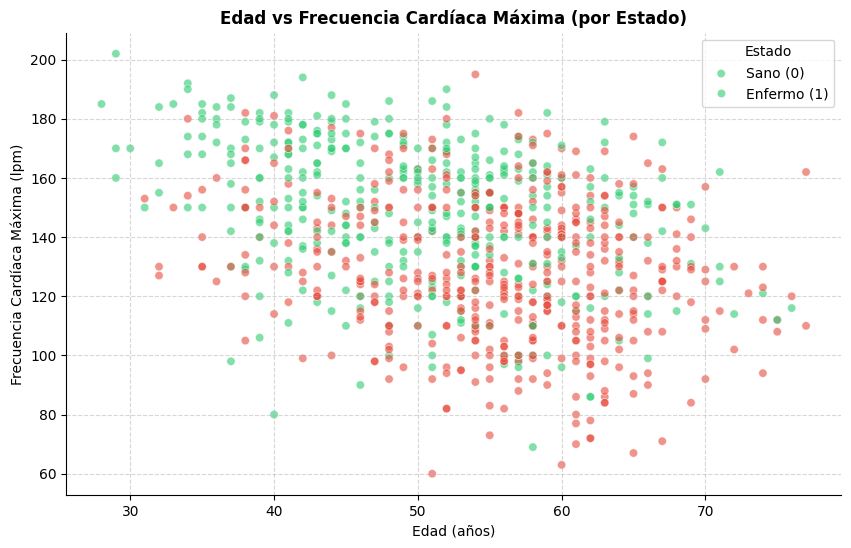

In [323]:
# Tu código de extensión aquí
# ⚡ Extensión 1: Más variables con Bayes - P(Enfermedad | sexo)
# Parámetros base
p_enfermedad = df['target'].mean()

for s in [0, 1]:
    etiqueta = "Hombres" if s == 1 else "Mujeres"

    p_sexo = (df['sex'] == s).mean()
    enfermos = df[df['target'] == 1]
    p_sexo_dado_enf = (enfermos['sex'] == s).mean()

    # Teorema de Bayes
    p_enf_dado_sexo = (p_sexo_dado_enf * p_enfermedad) / p_sexo
    print(f"P(Enfermedad | {etiqueta:7}): {p_enf_dado_sexo:.2%} (Bayes)")

print("\n--- Validación directa ---")
print(df.groupby('sex')['target'].mean())

# ⚡ Extensión 2: Otro T-test: Colesterol (chol)
# Se filtran valores 0 de colesterol (errores de carga comunes en este dataset)
chol_sanos = df[(df['target'] == 0) & (df['chol'] > 0)]['chol']
chol_enfermos = df[(df['target'] == 1) & (df['chol'] > 0)]['chol']

t_stat_chol, p_val_chol = stats.ttest_ind(chol_sanos, chol_enfermos)

print(f'Media Colesterol (Sanos):    {chol_sanos.mean():.2f}')
print(f'Media Colesterol (Enfermos): {chol_enfermos.mean():.2f}')
print(f'P-valor: {p_val_chol:.4f}')

# ⚡ Extensión 3: Visualización avanzada: age vs thalch
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='thalch', hue='target', alpha=0.6, palette={0: '#2ecc71', 1: '#e74c3c'})

plt.title('Edad vs Frecuencia Cardíaca Máxima (por Estado)', fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia Cardíaca Máxima (lpm)')
plt.legend(title='Estado', labels=['Sano (0)', 'Enfermo (1)'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Recursos recomendados



In [324]:
recursos = [
    "NumPy random (simulación): https://numpy.org/doc/stable/reference/random/index.html",
    "Khan Academy Probabilidad (ES): https://es.khanacademy.org/math/statistics-probability/probability-library",
    "3Blue1Brown – Bayes (muy visual): https://www.3blue1brown.com/",
    "Wikipedia Bayes (ES): https://es.wikipedia.org/wiki/Teorema_de_Bayes",
    "Matplotlib (plots básicos): https://matplotlib.org/stable/"
]
for r in recursos:
    print("-", r)

- NumPy random (simulación): https://numpy.org/doc/stable/reference/random/index.html
- Khan Academy Probabilidad (ES): https://es.khanacademy.org/math/statistics-probability/probability-library
- 3Blue1Brown – Bayes (muy visual): https://www.3blue1brown.com/
- Wikipedia Bayes (ES): https://es.wikipedia.org/wiki/Teorema_de_Bayes
- Matplotlib (plots básicos): https://matplotlib.org/stable/


## 📝 Resumen de lo aprendido

| Concepto | En palabras simples | Ejemplo |
|---|---|---|
| **Probabilidad básica** | Qué tan probable es algo, de 0 a 1 | P(cara) = 0.5 |
| **Prob. condicional** | La probabilidad cambia con nueva info | P(tarde \| lluvia) > P(tarde) |
| **Teorema de Bayes** | Actualizar creencias con evidencia | Test positivo ≠ estar enfermo |
| **Estadística Inferencial** | Analizar e interpretar datos | Predicciones sobre una población |